# Handling Missing Data

Missing data is one of the most common challenges in real-world datasets.  
Machine learning models cannot handle missing values directly, so they require a **complete dataset** to work properly.

### Why It Matters

Missing values, shown as `NaN` in Python, can:
- Distort averages, correlations, and statistics  
- Mislead visualizations or pattern detection  
- Prevent machine learning models from training correctly 

### Common Ways to Handle Missing Data

| Method     | When to Use | Description |
|------------|--------------|-------------|
| **Mean Imputation** | When numeric data is roughly balanced | Replace missing values with the column’s mean |
| **Median Imputation** | When numeric data has outliers or skewed distribution | Replace missing values with the median |
| **Mode Imputation** | For categorical data such as gender or city | Replace missing values with the most frequent value |
| **Dropping** | When only a small number of rows or columns are missing | Remove incomplete entries entirely |


In [94]:
# Import core data analysis and visualization libraries
import numpy as np                  # For numerical operations and arrays
import pandas as pd                 # For data handling, cleaning, and analysis
import seaborn as sns               # For statistical data visualization
import matplotlib.pyplot as plt     # For plotting charts and figures

# Import imputation tool from scikit-learn to handle missing data
from sklearn.impute import SimpleImputer

## 1) Load and Preview the Dataset

The Titanic dataset is loaded from Seaborn’s built-in collection.  
- It contains information about passengers such as **age**, **fare**, **class**, **gender**, and **whether they survived**.  

In [95]:
# Load the Titanic dataset from Seaborn’s sample datasets
titanic = sns.load_dataset("titanic")

# Display the first five rows to understand the data structure
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2) Measure Missingness

The first step in handling missing data is to check how much of it exists.  
(Counting missing values helps identify which columns are most affected and guides whether to **fill** or **drop** them).

- `.isna().sum()` counts missing values per column.  
- Summing again gives the **total number of missing cells** in the entire dataset.  
- A bar plot provides a quick visual summary, showing which features need the most attention.


Total missing cells: 869


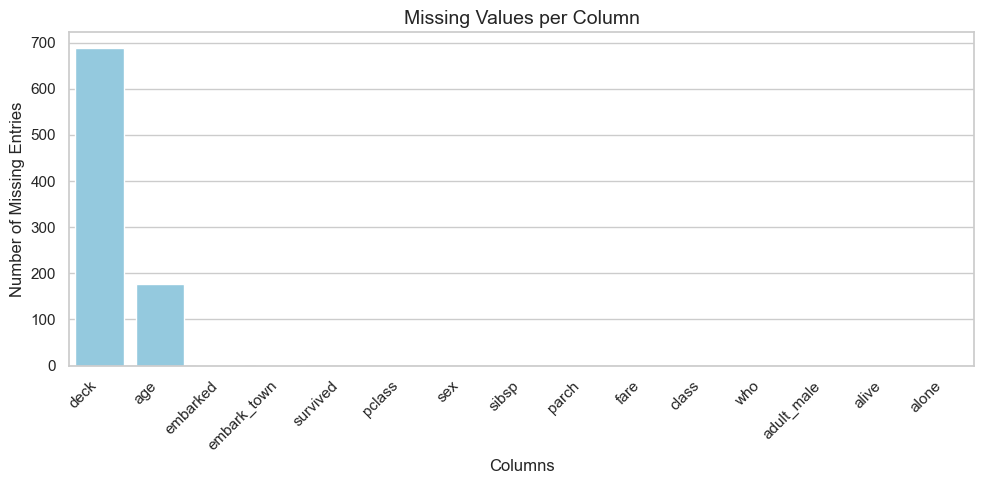

In [96]:
# Count the number of missing values in each column, sorted from highest to lowest
missing_per_col = titanic.isna().sum().sort_values(ascending=False)

# Print the total number of missing cells in the dataset
print("Total missing cells:", titanic.isna().sum().sum())

# Display the top 10 columns with the most missing values
missing_per_col.head(10)

# ----------------------------------------------
# Visualize missingness across features
# ----------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_per_col.index, y=missing_per_col.values, color="skyblue")
plt.title("Missing Values per Column", fontsize=14)
plt.ylabel("Number of Missing Entries")
plt.xlabel("Columns")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpreting the Missing Values Chart

The bar chart shows how many entries are missing in each column of the Titanic dataset.

- **`deck`** has the highest number of missing values (nearly 700).  
  - Most passengers’ cabin deck information was not recorded, making this column largely incomplete.  
    - Because so much data is missing, it is usually **dropped** instead of being filled.

- **`age`** has around 170 missing entries.  
  - Age is an important feature for understanding survival patterns, so it should be **imputed** rather than removed.  

All other columns are complete, containing no missing data.  

## 3) Visualize the Distribution of a Numeric Column

Before deciding how to fill missing values, it is essential to understand how the data is distributed.  
This step helps determine whether to use the **mean** or **median** for imputation.

Two plots are created for the `age` column:
1. A **histogram with a density curve (KDE)** to show the overall shape and spread of the data.
2. A **boxplot** to highlight the median, quartiles, and potential outliers.

The **skewness value** quantifies how asymmetric the data is:
- A skewness close to 0 indicates a roughly symmetric (normal) distribution.  
- A positive skew means the data is pulled to the right (a few high values).  
- A negative skew means the data is pulled to the left (a few low values).

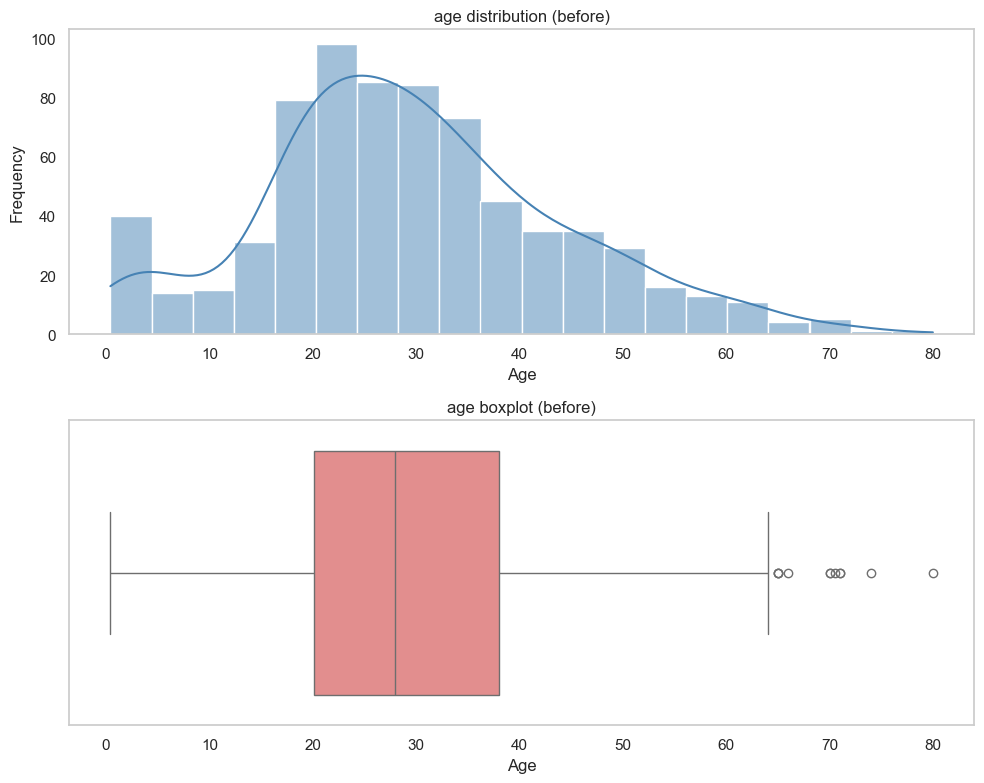

Skewness of age: 0.38910778230082704


In [97]:
# Select the numeric column to analyze
num_col = "age"

# Create a figure with 1 column and 2 rows for stacked plots
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Plot histogram with KDE to visualize distribution shape
sns.histplot(df[num_col], kde=True, ax=ax[0], color="steelblue")
ax[0].set_title(f"{num_col} distribution (before)")
ax[0].set_xlabel(num_col.capitalize())
ax[0].set_ylabel("Frequency")
ax[0].grid(False)

# Plot boxplot to detect outliers and show the median
sns.boxplot(x=df[num_col], ax=ax[1], color="lightcoral")
ax[1].set_title(f"{num_col} boxplot (before)")
ax[1].set_xlabel(num_col.capitalize())
ax[1].grid(False)

# Adjust spacing for readability
plt.tight_layout()
plt.show()

# Calculate and display skewness to measure asymmetry
print(f"Skewness of {num_col}:", df[num_col].skew())

### Interpreting the Distribution and Skewness

The histogram shows that most passengers are between **20 and 40 years old**, with fewer older passengers.  
The boxplot confirms a few mild outliers (some passengers much older than the rest).

The **skewness value is 0.39**, which means the distribution is **slightly right-skewed** but not extremely distorted.  
This suggests that:
- The data is **not perfectly symmetric**, so the mean might be slightly influenced by higher values.  
- However, the skewness is **below 0.5**, meaning it is only mildly skewed.

> In this case, both **mean** and **median** imputation would work reasonably well, but **median imputation** is generally safer since it is less affected by the few higher ages.

### 4) Median Imputation for `age`

After confirming that the `age` column is slightly right-skewed, the **median** is chosen for imputation.  
The median is the middle value of the dataset and is **not affected by outliers**, making it ideal for skewed numeric data.

Steps performed:
1. Create a copy of the original DataFrame to preserve raw data.  
2. Compute the median value of the `age` column.  
3. Replace all missing entries in `age` with this median value.  
4. Re-plot the distribution and boxplot to verify that the data now has no missing values and maintains a similar shape.

Remaining missing in age: 0


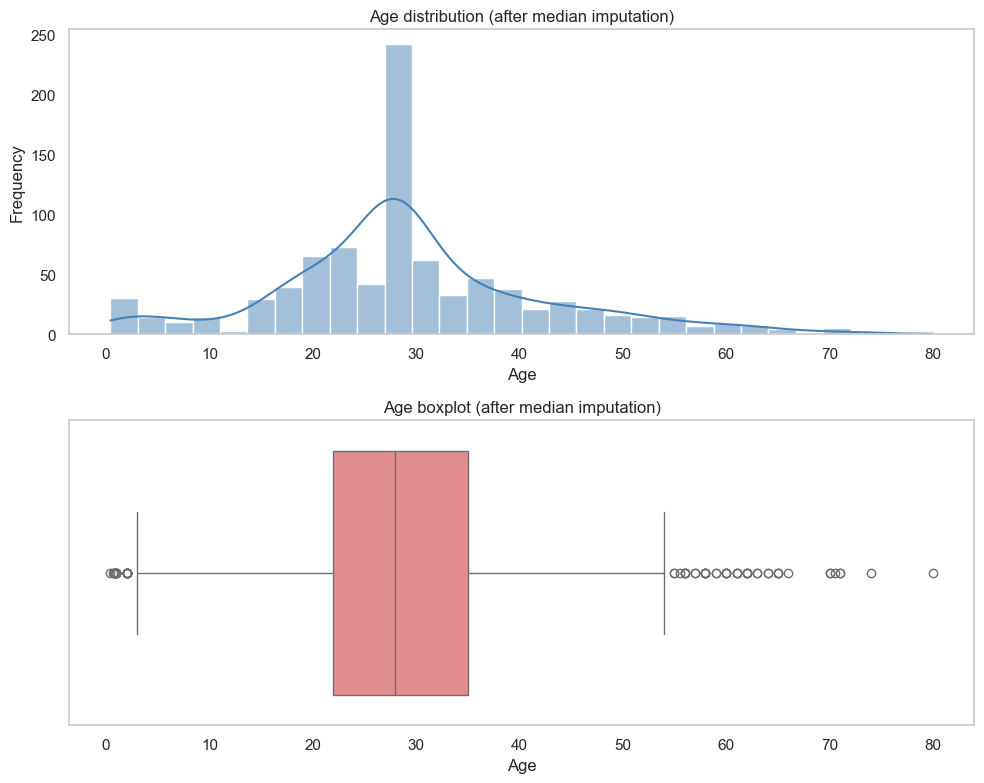

In [98]:
# Create a copy of the dataset to avoid altering the original
df_imp = df.copy()

# Calculate the median of the 'age' column
median_age = df_imp["age"].median()

# Replace missing values in 'age' with the median
df_imp["age"] = df_imp["age"].fillna(median_age)

# Verify that all missing values have been filled
print("Remaining missing in age:", df_imp["age"].isna().sum())

# ---------------------------------------------------------
# Visualize the distribution after median imputation
# ---------------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Histogram with KDE to check overall shape
sns.histplot(df_imp["age"], kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Age distribution (after median imputation)")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Frequency")
ax[0].grid(False)

# Boxplot to confirm reduced gaps and no missing data
sns.boxplot(x=df_imp["age"], ax=ax[1], color="lightcoral")
ax[1].set_title("Age boxplot (after median imputation)")
ax[1].set_xlabel("Age")
ax[1].grid(False)

plt.tight_layout()
plt.show()

## 4) Dropping Missing Data

Sometimes it is better to **remove rows or columns** that contain too many missing values, especially when:

- Only a **small number of rows** are incomplete (dropping them will not affect the dataset much).  
- A **column has more than 50% missing values**, making it unreliable for analysis.  

However, dropping data should be the **last option** because it reduces the amount of information available for the model.

In [99]:
# ---------------------------------------------------------------------
# Drop rows that contain any missing values
# ---------------------------------------------------------------------
# 'how="any"' means a row will be removed if ANY column in it is NaN
df_rows_dropped = df.dropna(how="any")
print("Original:", df.shape, "| After dropping rows:", df_rows_dropped.shape)

# ---------------------------------------------------------------------
# Identify columns with more than 50% missing values
# ---------------------------------------------------------------------
# Calculate the percentage of missing values per column
# Drop those columns since they contribute little reliable information
to_drop = [c for c in df.columns if df[c].isna().mean() > 0.5]

# Display which columns would be dropped
print("Columns dropped (>50% missing):", to_drop)

Original: (891, 15) | After dropping rows: (182, 15)
Columns dropped (>50% missing): ['deck']
